## Analysis of the obtained results

In [37]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [38]:
from datasets import load_dataset
import pandas as pd


## Loading the MGSD dataset.

dataset = load_dataset("wu981526092/MGSD")

data = dataset['train']
df = data.to_pandas()


## Loading the MentalManip dataset

dataset_2 = load_dataset("audreyeleven/MentalManip", "mentalmanip_maj")
data_2 = dataset_2["train"]
df_2 = data_2.to_pandas()
from data_loader import load_mgsd_dataset, load_mentalmanip_dataset

sample_sizes_mgsd = {
    'stereotype': 250,
    'unrelated': 250,
}

sample_size_examples_mgsd = {
    'stereotype': 5,
    'unrelated': 5
}

sample_sizes_manip = {1: 250, 0: 250}
sample_sizes_examples_manip = {1: 5, 0: 5}
max_len_examples = 1000

sample_mgsd, sample_examples_mgsd = load_mgsd_dataset(
    df, 
    sample_sizes_mgsd, 
    sample_size_examples_mgsd,
    random_state=42,
    random_state_examples=0,
    )

sample_mentalmanip, sample_examples_mentalmanip = load_mentalmanip_dataset(
    df_2, 
    sample_sizes_manip, 
    sample_sizes_examples_manip, 
    max_len_examples,
    random_state=42,
    random_state_examples=0,
    )

Some datasets params were ignored: ['license']. Make sure to use only valid params for the dataset builder and to have a up-to-date version of the `datasets` library.


## Role Playing Core

### Zero-shot

🔍 Found 12 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'original_dataset', 'profile1_active', 'profile1_passive', 'profile2_active', 'profile2_passive', 'profile3_active', 'profile3_passive', 'profile4_active', 'profile4_passive', 'profile5_active', 'profile5_passive', 'profile6_active', 'profile6_passive', 'stereotype_type']



=== Accuracy Improvements vs Baseline
profile1_active: Δ = -0.0320
profile1_passive: Δ = -0.0200
profile2_active: Δ = -0.0140
profile2_passive: Δ = -0.0240
profile3_active: Δ = -0.0360
profile3_passive: Δ = -0.0240
profile4_active: Δ = -0.0240
profile4_passive: Δ = -0.0300
profile5_active: Δ = -0.0340
profile5_passive: Δ = -0.0120
profile6_active: Δ = -0.0220
profile6_passive: Δ = -0.0140

=== McNemar p-values:
profile1_active: p = 0.0070, stat = 8.00
profile1_passive: p = 0.0987, stat = 10.00
profile2_active: p = 0.2295, stat = 9.00
profile2_passive: p = 0.0227, stat = 6.00
profile3_active: p = 0.001

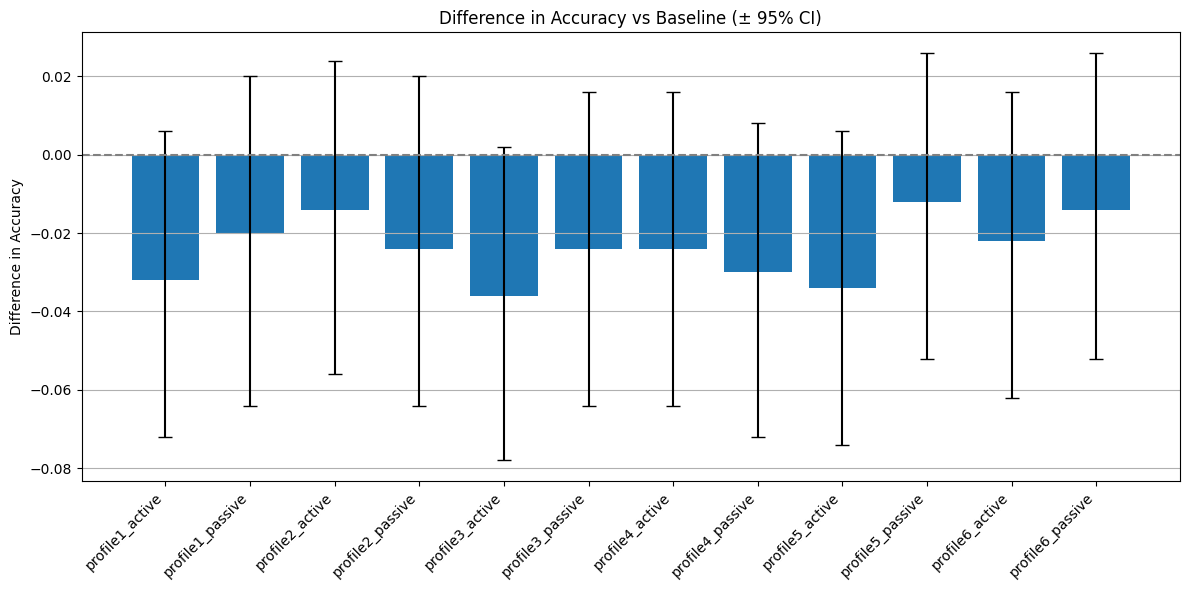

=== Classification Reports Summary ===

         profile  accuracy  f1_macro  f1_weighted  precision_macro  recall_macro
        baseline     0.720     0.714        0.714            0.739         0.720
profile5_passive     0.708     0.702        0.702            0.726         0.708
 profile2_active     0.706     0.700        0.700            0.724         0.706
profile6_passive     0.706     0.699        0.699            0.726         0.706
profile1_passive     0.700     0.693        0.693            0.720         0.700
 profile6_active     0.698     0.692        0.692            0.715         0.698
profile2_passive     0.696     0.689        0.689            0.715         0.696
profile3_passive     0.696     0.689        0.689            0.715         0.696
 profile4_active     0.696     0.689        0.689            0.715         0.696
profile4_passive     0.690     0.683        0.683            0.709         0.690
 profile1_active     0.688     0.681        0.681            0.707   

In [42]:
from analysis_tools import *
from utils_visualisation import plot_accuracy_deltas_with_ci

merged = load_and_merge_profiles(
    base_file_path="results/openai_4.1_mini/zero_shot/classic/results_stereotype_zero_shot_prompt_short_binary.csv",
    role_playing_glob_pattern="results/openai_4.1_mini/zero_shot/role_playing_core/*/results_stereotype_zero_shot_prompt_short_binary.csv",
    sample_df=sample_mgsd
)

report = evaluate_role_playing_effects(merged)
print("\n\n")
print_report(report)
plot_accuracy_deltas_with_ci(merged)

summary_df = compute_classification_reports(merged)
cat_stats = rescue_stats_by_category(merged,
                                     category_col="stereotype_type",
                                     baseline_col="base_pred",
                                     label_col="true_label")

print(cat_stats.to_string(index=False, float_format="%.3f"))

### Few-shots

🔍 Found 12 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'original_dataset', 'profile1_active', 'profile1_passive', 'profile2_active', 'profile2_passive', 'profile3_active', 'profile3_passive', 'profile4_active', 'profile4_passive', 'profile5_active', 'profile5_passive', 'profile6_active', 'profile6_passive', 'stereotype_type']



=== Accuracy Improvements vs Baseline
profile1_active: Δ = -0.0080
profile1_passive: Δ = 0.0060
profile2_active: Δ = -0.0100
profile2_passive: Δ = 0.0000
profile3_active: Δ = 0.0080
profile3_passive: Δ = 0.0160
profile4_active: Δ = 0.0060
profile4_passive: Δ = 0.0140
profile5_active: Δ = -0.0060
profile5_passive: Δ = 0.0100
profile6_active: Δ = -0.0160
profile6_passive: Δ = 0.0120

=== McNemar p-values:
profile1_active: p = 0.6358, stat = 18.00
profile1_passive: p = 0.7608, stat = 20.00
profile2_active: p = 0.5224, stat = 17.00
profile2_passive: p = 1.0000, stat = 18.00
profile3_active: p = 0.6271, st

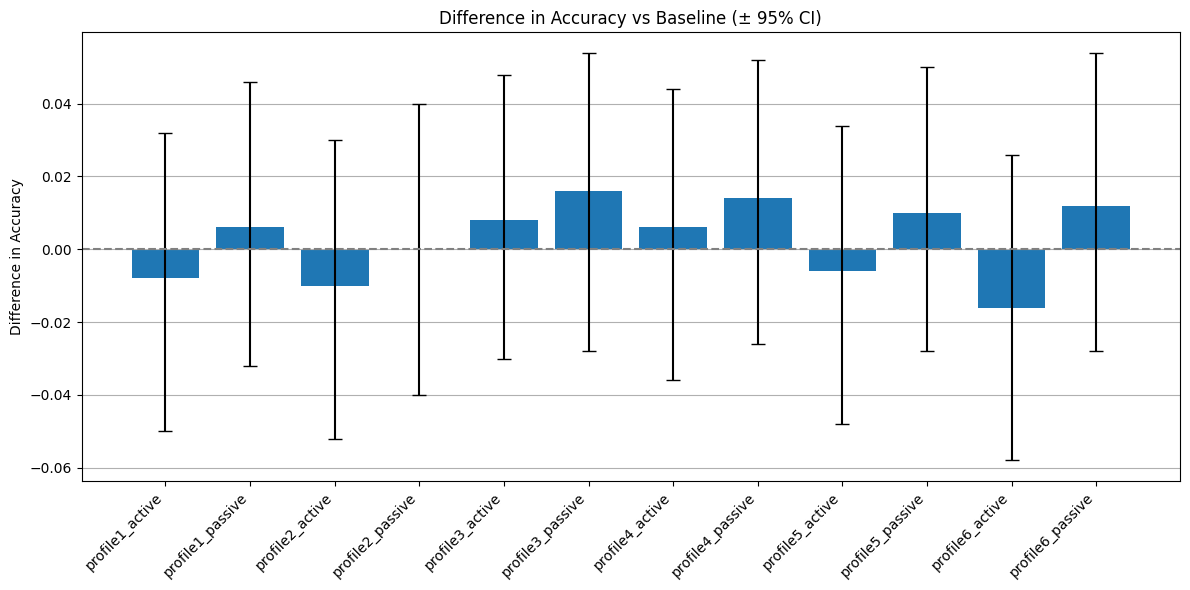

=== Classification Reports Summary ===

         profile  accuracy  f1_macro  f1_weighted  precision_macro  recall_macro
profile3_passive     0.716     0.715        0.715            0.720         0.716
profile4_passive     0.714     0.713        0.713            0.717         0.714
profile6_passive     0.712     0.710        0.710            0.717         0.712
profile5_passive     0.710     0.706        0.706            0.721         0.710
 profile3_active     0.708     0.706        0.706            0.715         0.708
 profile4_active     0.706     0.705        0.705            0.708         0.706
profile1_passive     0.706     0.704        0.704            0.711         0.706
        baseline     0.700     0.697        0.697            0.708         0.700
profile2_passive     0.700     0.696        0.696            0.710         0.700
 profile5_active     0.694     0.690        0.690            0.704         0.694
 profile1_active     0.692     0.689        0.689            0.699   

In [43]:
from utils_visualisation import plot_accuracy_deltas_with_ci

merged = load_and_merge_profiles(
    base_file_path="results/openai_4.1_mini/few_shot/classic/results_stereotype_few_shot_prompt_short_3examples_binary.csv",
    role_playing_glob_pattern="results/openai_4.1_mini/few_shot/role_playing_core/*/results_stereotype_few_shot_prompt_short_3examples_binary.csv",
    sample_df=sample_mgsd
)

report = evaluate_role_playing_effects(merged)
print("\n\n")
print_report(report)
plot_accuracy_deltas_with_ci(merged)

summary_df = compute_classification_reports(merged)
cat_stats = rescue_stats_by_category(merged,
                                     category_col="stereotype_type",
                                     baseline_col="base_pred",
                                     label_col="true_label")

print(cat_stats.to_string(index=False, float_format="%.3f"))

## Analysis results zero-shot

In [ ]:
from analysis_tools import (
    load_and_merge_profiles,
    rescue_stats_by_category,
    detect_systematic_biases,
    analyze_temporal_stability,
    extract_high_disagreement_cases,
    analyze_persona_similarity,
    test_comprehensive_own_group_sensitivity,
    print_comprehensive_own_group_results
)

merged_df = load_and_merge_profiles(
    base_file_path="results/openai_4.1_mini/zero_shot/classic/results_stereotype_zero_shot_prompt_short_binary.csv",
    role_playing_glob_pattern="results/openai_4.1_mini/zero_shot/role_playing_system/*/results_stereotype_zero_shot_prompt_short_binary.csv",
    sample_df=sample_mgsd
)

#factorial_results = tools["run_factorial_analysis"](merged_df)
comprehensive_results = test_comprehensive_own_group_sensitivity(merged_df)
significant_findings = print_comprehensive_own_group_results(comprehensive_results)

🔍 Found 30 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'original_dataset', 'profile10_passive', 'profile11_passive', 'profile12_passive', 'profile13_passive', 'profile14_passive', 'profile15_passive', 'profile16_passive', 'profile17_passive', 'profile18_passive', 'profile19_passive', 'profile1_passive', 'profile20_passive', 'profile21_passive', 'profile22_passive', 'profile23_passive', 'profile24_passive', 'profile25_passive', 'profile26_passive', 'profile27_passive', 'profile28_passive', 'profile29_passive', 'profile2_passive', 'profile30_passive', 'profile3_passive', 'profile4_passive', 'profile5_passive', 'profile6_passive', 'profile7_passive', 'profile8_passive', 'profile9_passive', 'stereotype_type']

COMPREHENSIVE OWN-GROUP SENSITIVITY ANALYSIS

=== RACE STEREOTYPE HANDLING ===
Individual group performance on race stereotypes:
  White personas: 0.7025
  Black personas: 0.6930
  Asian personas: 0.6996

  Best performing:


=== HIGH DISAGREEMENT CASES ===
     sample_id  disagreement_score                          predictions  \
24          24            0.500000  {'stereotype': 15, 'unrelated': 15}   
450        450            0.500000  {'stereotype': 15, 'unrelated': 15}   
226        226            0.466667  {'unrelated': 16, 'stereotype': 14}   
232        232            0.466667  {'stereotype': 16, 'unrelated': 14}   
104        104            0.433333  {'stereotype': 17, 'unrelated': 13}   
121        121            0.433333  {'stereotype': 17, 'unrelated': 13}   
328        328            0.433333  {'stereotype': 13, 'unrelated': 17}   
279        279            0.400000  {'stereotype': 18, 'unrelated': 12}   
318        318            0.400000  {'stereotype': 18, 'unrelated': 12}   
258        258            0.366667  {'stereotype': 19, 'unrelated': 11}   

     true_label   base_pred  
24   stereotype  stereotype  
450  stereotype  stereotype  
226  stereotype  stereotype  
232   unrelated   unr

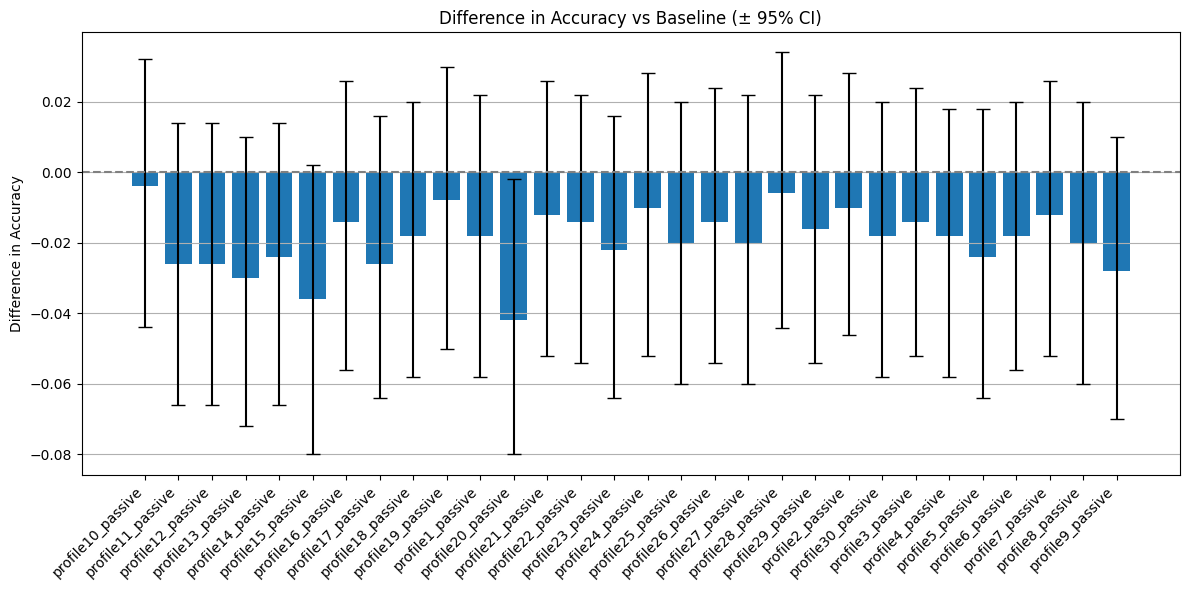

In [46]:
disagreement_cases = extract_high_disagreement_cases(merged_df, threshold=0.3)
print("\n=== HIGH DISAGREEMENT CASES ===")
print(disagreement_cases.head(10))

bias_patterns = detect_systematic_biases(merged_df)
print("\n=== SYSTEMATIC BIAS PATTERNS ===")
print(bias_patterns.head(20))

rescue_stats = rescue_stats_by_category(merged_df, category_col="stereotype_type")
print("\n=== RESCUE STATISTICS BY CATEGORY ===")
print(rescue_stats[rescue_stats['category'] == 'race'].head(10))

plot_accuracy_deltas_with_ci(merged_df)

In [47]:
similarity_results = analyze_persona_similarity(merged_df)
print("\n=== PERSONA CLUSTERING ===")
for cluster_id, cluster_info in similarity_results['clusters'].items():
    print(f"{cluster_id}: {cluster_info['profiles']}")
    print(f"  Average accuracy: {cluster_info['avg_accuracy']:.4f}")

stability_results = analyze_temporal_stability(merged_df, n_folds=5)
print("\n=== TEMPORAL STABILITY ===")
for profile, stats in list(stability_results.items())[:5]:
    print(f"{profile}: mean={stats['mean_accuracy']:.4f}, std={stats['std_accuracy']:.4f}")


=== PERSONA CLUSTERING ===
cluster_1: ['profile12_passive', 'profile18_passive', 'profile1_passive', 'profile24_passive', 'profile25_passive', 'profile28_passive', 'profile2_passive', 'profile3_passive', 'profile5_passive', 'profile7_passive', 'profile8_passive']
  Average accuracy: 0.7038
cluster_2: ['profile20_passive', 'profile23_passive', 'profile29_passive', 'profile6_passive']
  Average accuracy: 0.6955
cluster_3: ['profile10_passive', 'profile11_passive', 'profile13_passive', 'profile14_passive', 'profile15_passive', 'profile16_passive', 'profile17_passive', 'profile19_passive', 'profile21_passive', 'profile22_passive', 'profile26_passive', 'profile27_passive', 'profile30_passive', 'profile4_passive', 'profile9_passive']
  Average accuracy: 0.7005

=== TEMPORAL STABILITY ===
profile10_passive: mean=0.7160, std=0.0215
profile11_passive: mean=0.6940, std=0.0314
profile12_passive: mean=0.6940, std=0.0338
profile13_passive: mean=0.6900, std=0.0303
profile14_passive: mean=0.6960, st

Running Tier 1 Analysis: 3-Way Factorial ANOVA...

FACTORIAL ANOVA: ACCURACY
GENDER MAIN EFFECT:
  Male mean: 0.6997
  Female mean: 0.7024
  Difference: 0.0027
  p-value: 0.4023 
  Cohen's d: 0.321

ETHNICITY MAIN EFFECT:
  White mean: 0.7034
  Black mean: 0.6950
  Asian mean: 0.7048
  F-statistic: 4.875
  p-value: 0.0156 ***

COGNITIVE STYLE MAIN EFFECT:
  Balanced mean: 0.6960
  Expansive mean: 0.7030
  Literal mean: 0.7020
  High_Harm mean: 0.7017
  Low_Harm mean: 0.7027
  F-statistic: 0.649
  p-value: 0.6329 

INTERACTION EFFECTS:
  Male White: 0.7032
  Male Black: 0.6916
  Male Asian: 0.7044
  Female White: 0.7036
  Female Black: 0.6984
  Female Asian: 0.7052

FACTORIAL ANOVA: RESCUE_RATE
GENDER MAIN EFFECT:
  Male mean: 0.0440
  Female mean: 0.0442
  Difference: 0.0002
  p-value: 0.9800 
  Cohen's d: 0.010

ETHNICITY MAIN EFFECT:
  White mean: 0.0635
  Black mean: 0.0293
  Asian mean: 0.0394
  F-statistic: 8.852
  p-value: 0.0011 ***

COGNITIVE STYLE MAIN EFFECT:
  Balanced mean:

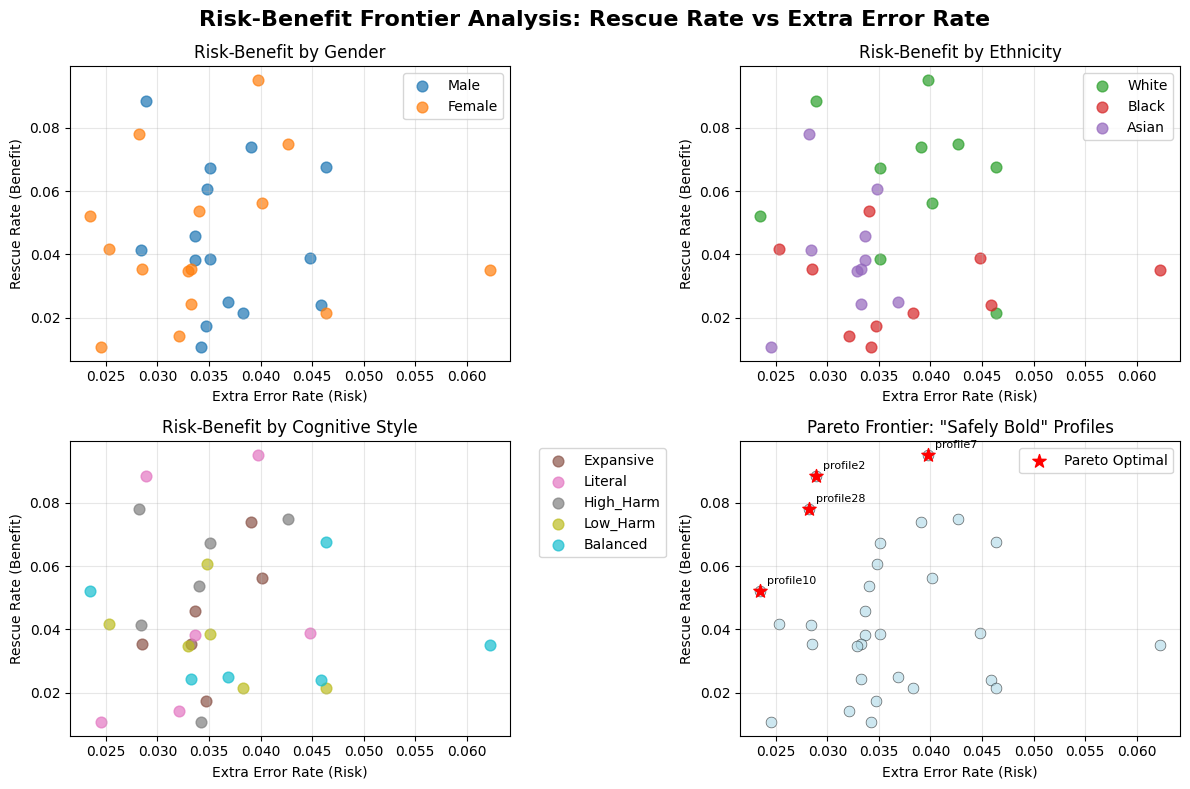


PARETO FRONTIER ANALYSIS

Pareto Optimal Profiles (Safely Bold):
  profile10_passive: Female White Balanced
    Rescue Rate: 0.052, Extra Error Rate: 0.023
  profile28_passive: Female Asian High_Harm
    Rescue Rate: 0.078, Extra Error Rate: 0.028
  profile2_passive: Male White Literal
    Rescue Rate: 0.088, Extra Error Rate: 0.029
  profile7_passive: Female White Literal
    Rescue Rate: 0.095, Extra Error Rate: 0.040

Risk-Benefit Statistics:
  Average rescue rate: 0.044
  Average extra error rate: 0.036
  Best rescue rate: 0.095
  Lowest extra error rate: 0.023

Profile Archetypes:
  Safest Profile: profile10_passive (Female White Balanced)
    Extra Error Rate: 0.023
  Most Beneficial Profile: profile7_passive (Female White Literal)
    Rescue Rate: 0.095
Calculating Effect Sizes...

EFFECT SIZE ANALYSIS (Cohen's d)

black_women_race_vs_gender:
  Cohen's d: 6.029 (large effect)
  Mean difference: 0.0991
  Race stereotypes: 0.6959
  Gender stereotypes: 0.5968


In [48]:
from analysis_tools import factorial_analysis_3way_anova, plot_risk_benefit_frontier, calculate_effect_sizes

print("Running Tier 1 Analysis: 3-Way Factorial ANOVA...")
factorial_results = factorial_analysis_3way_anova(merged_df)

print("Creating Risk-Benefit Frontier...")
risk_benefit_results = plot_risk_benefit_frontier(merged_df)

print("Calculating Effect Sizes...")
effect_sizes = calculate_effect_sizes(merged_df, significant_findings)

🚀 Running Tier 2 Analysis...
🚀 EXECUTING TIER 2 ANALYSIS PIPELINE

📊 Running Ensemble by Trait Analysis...
ENSEMBLE BY TRAIT ANALYSIS
Baseline accuracy: 0.7200

Ensemble Performance by Trait Group:
--------------------------------------------------
ALL_PROFILES   : 0.6960 (-0.0240) | Rescue: 0.029 | Extra Err: 0.044 | n=30
MEN_ONLY       : 0.7000 (-0.0200) | Rescue: 0.029 | Extra Err: 0.039 | n=15
WOMEN_ONLY     : 0.7000 (-0.0200) | Rescue: 0.029 | Extra Err: 0.039 | n=15
WHITE_ONLY     : 0.6980 (-0.0220) | Rescue: 0.043 | Extra Err: 0.047 | n=10
BLACK_ONLY     : 0.6960 (-0.0240) | Rescue: 0.014 | Extra Err: 0.039 | n=10
ASIAN_ONLY     : 0.7060 (-0.0140) | Rescue: 0.036 | Extra Err: 0.033 | n=10
EXPANSIVE_ONLY : 0.7060 (-0.0140) | Rescue: 0.043 | Extra Err: 0.036 | n=6
LITERAL_ONLY   : 0.7020 (-0.0180) | Rescue: 0.043 | Extra Err: 0.042 | n=6
HIGH_HARM_ONLY : 0.7080 (-0.0120) | Rescue: 0.050 | Extra Err: 0.036 | n=6
LOW_HARM_ONLY  : 0.6980 (-0.0220) | Rescue: 0.021 | Extra Err: 0.039 |

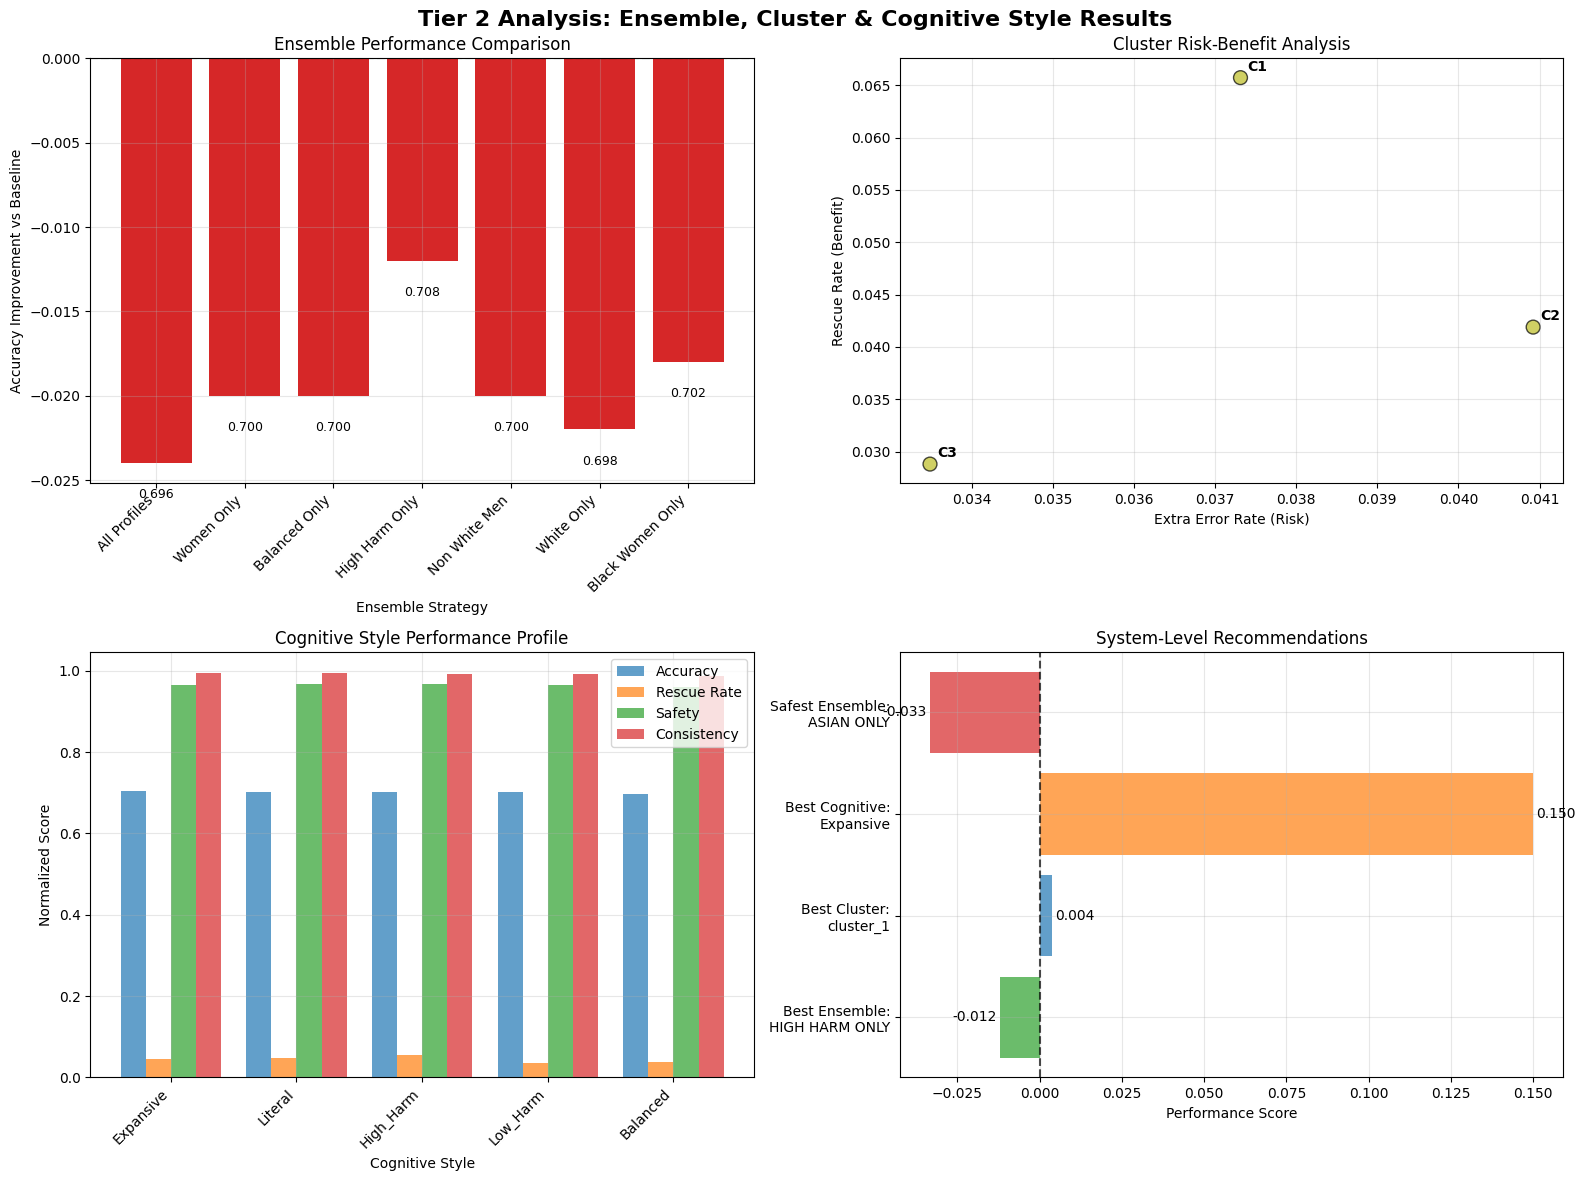


TIER 2 EXECUTIVE SUMMARY

🎯 KEY FINDINGS:
   • Best Ensemble Strategy: HIGH_HARM_ONLY
   • Best Cluster: cluster_1
   • Best Cognitive Style: Expansive

📈 PERFORMANCE GAINS:
   • Best Ensemble Improvement: +-0.0120
   • Safety-Performance Balance Achieved

🛡️ SAFETY INSIGHTS:
   • Safest Strategy: ASIAN_ONLY
   • Minimum Extra Error Rate: 0.033
Best ensemble strategy: HIGH_HARM_ONLY
Performance improvement: +-0.0120


In [49]:
from analysis_tools import run_tier2_analysis
# Run complete Tier 2 analysis
print("🚀 Running Tier 2 Analysis...")
tier2_results = run_tier2_analysis(merged_df)

# Access key recommendations
executive_summary = tier2_results['executive_summary']
print(f"Best ensemble strategy: {executive_summary['best_ensemble']}")
print(f"Performance improvement: +{executive_summary['performance_improvement']:.4f}")

🚀 Running Tier 3 Analysis...
🚀 EXECUTING TIER 3 ANALYSIS PIPELINE

⏱️ Running Temporal Stability vs Boldness Analysis...
TEMPORAL STABILITY vs BOLDNESS TRADEOFF ANALYSIS
📊 Calculating temporal stability across 5 folds...
⚡ Calculating boldness metrics...
🔗 Analyzing stability-boldness correlations...

📈 CORRELATION RESULTS:
  Volatility vs Boldness: r=-0.154, p=0.4158 
  Volatility vs Rescue Rate: r=-0.154, p=0.4158 
  Boldness vs Accuracy: r=0.526, p=0.0028 ***

🎯 PROFILE CLASSIFICATION:
  profile10: ⚡ Stable Bold - Best of both worlds
    Volatility: 0.0215, Boldness: 0.021, Rescue: 0.052, Accuracy: 0.7160
  profile11: 🎲 Volatile Cautious - High risk, low moral value
    Volatility: 0.0314, Boldness: 0.007, Rescue: 0.018, Accuracy: 0.6940
  profile12: 🌪️ Volatile Bold - High risk, high moral value
    Volatility: 0.0338, Boldness: 0.016, Rescue: 0.039, Accuracy: 0.6940
  profile13: 🎲 Volatile Cautious - High risk, low moral value
    Volatility: 0.0303, Boldness: 0.004, Rescue: 0.011

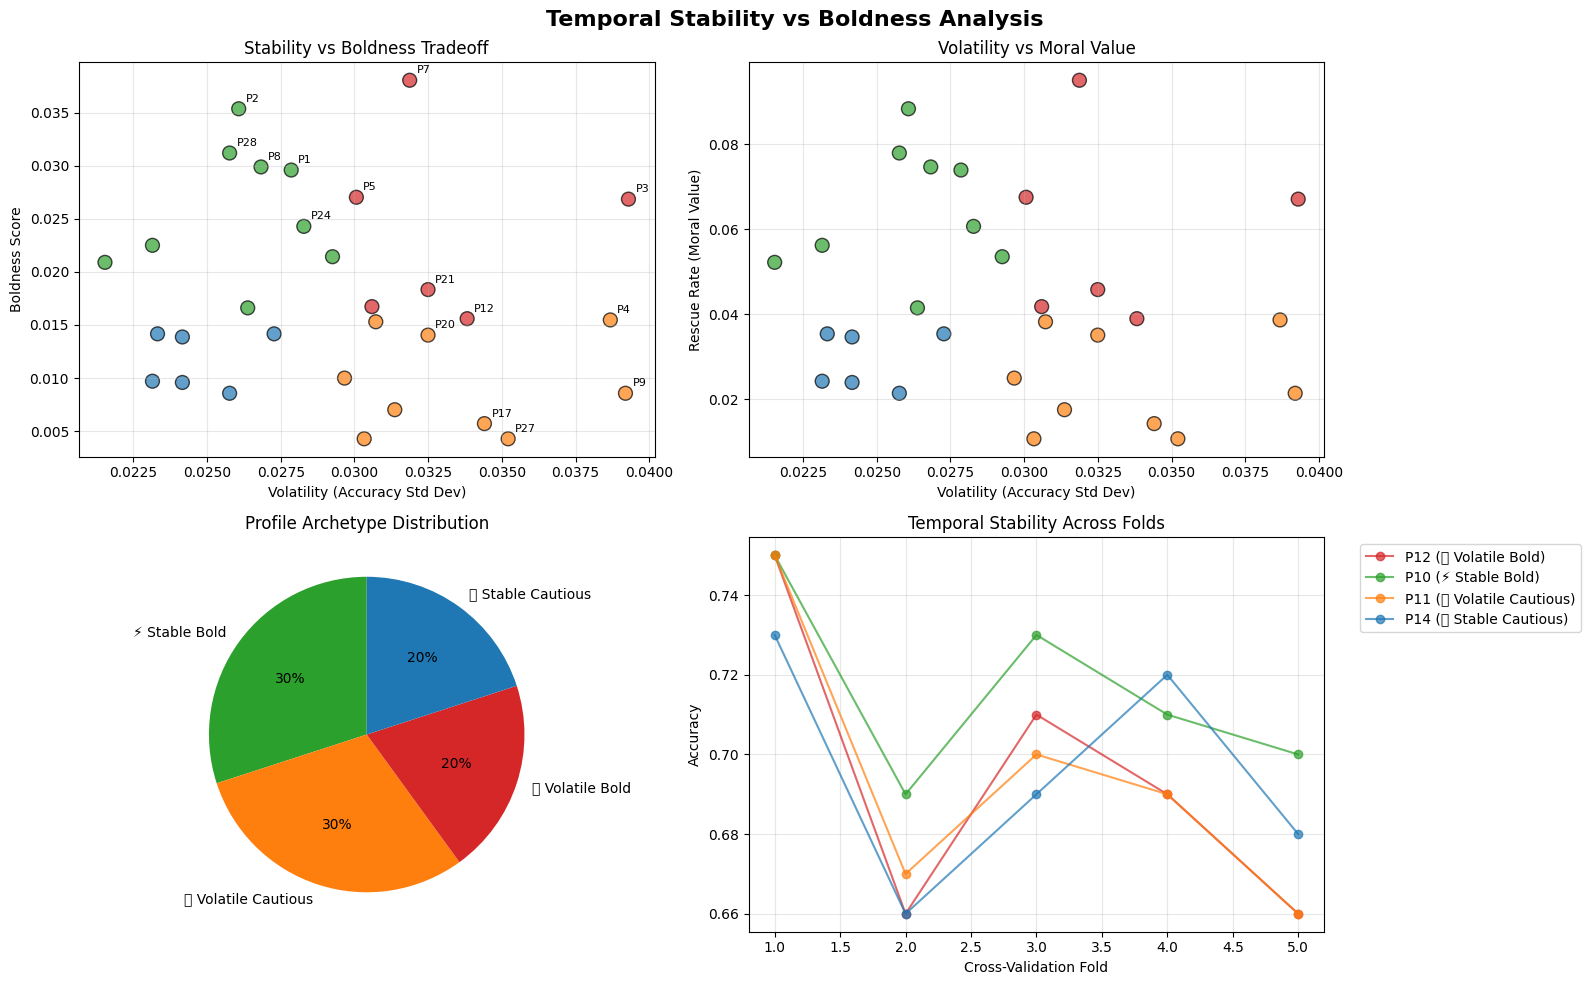


🧠 Creating Causal Model Visualizations...


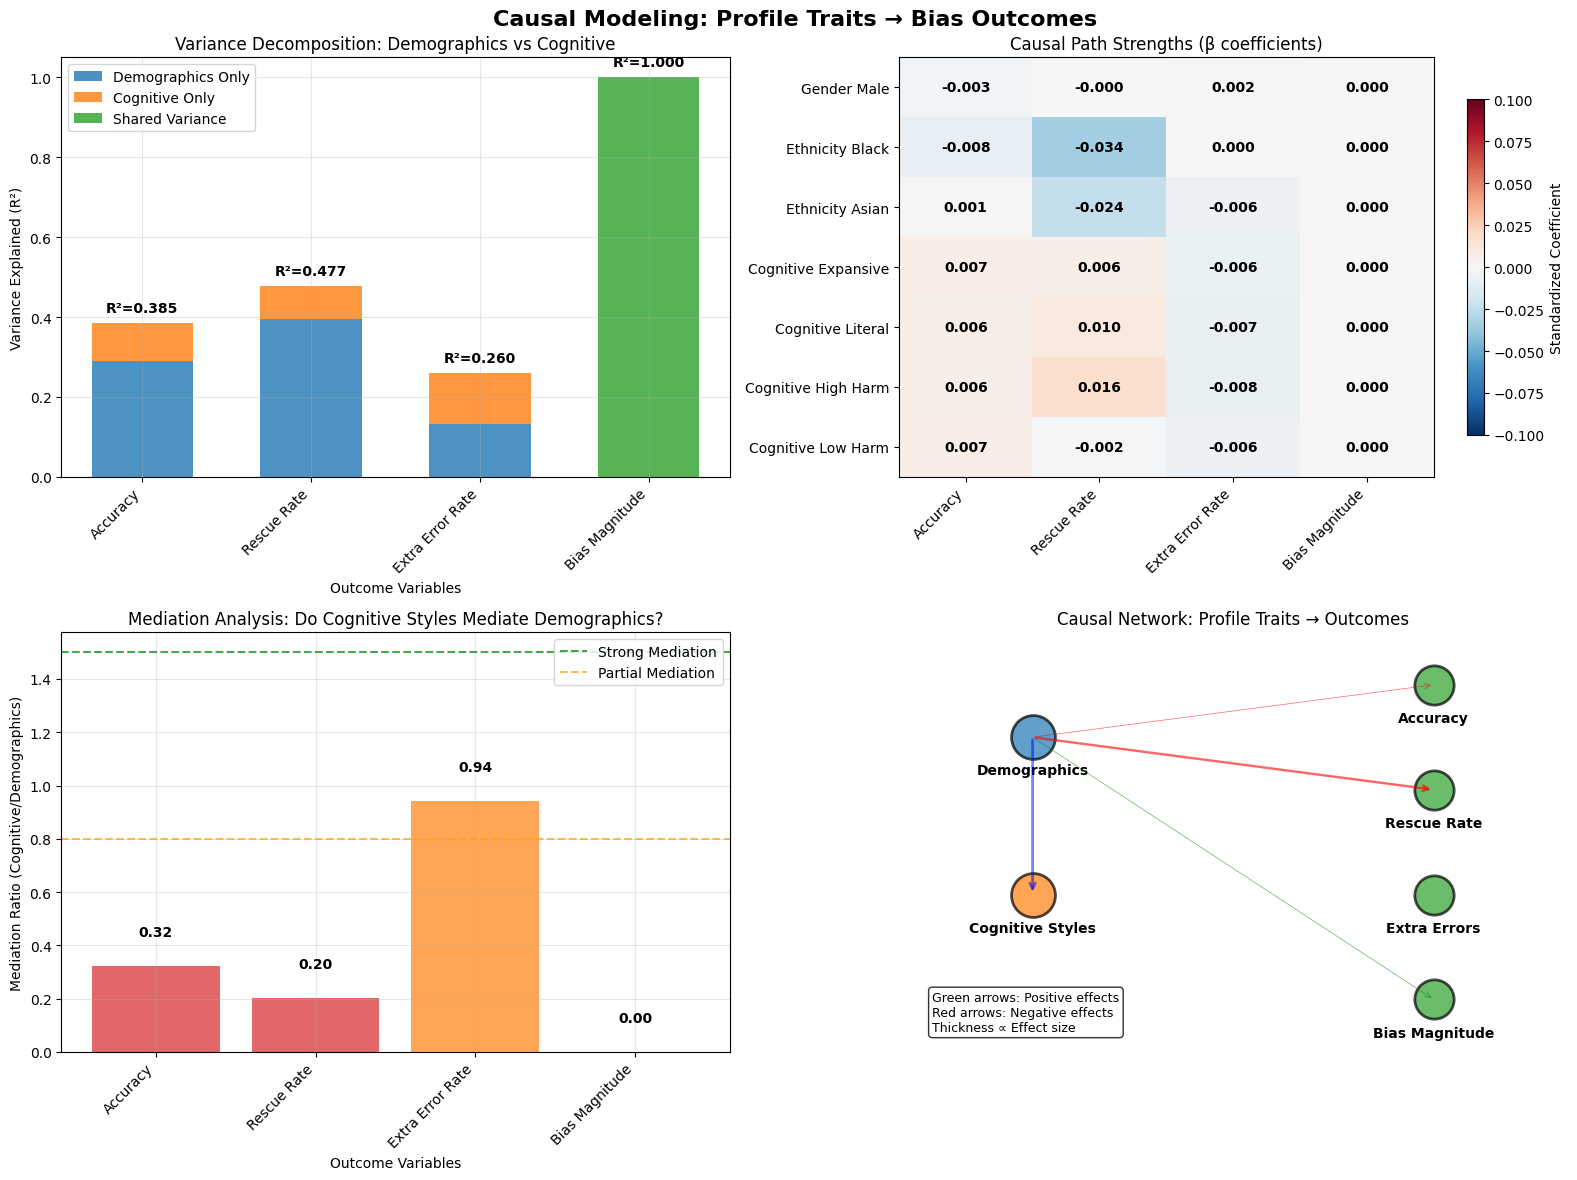


TIER 3 THEORETICAL INTEGRATION

🧠 THEORETICAL INSIGHTS:
   • ❌ Stable profiles outperform volatile ones in moral value
   • Implication: Consistency should be prioritized over boldness in AI systems
   • Strongest predictor of moral value (rescue): ethnicity_black
   • Strongest predictor of performance (accuracy): ethnicity_black
   • Mediation effects found: extra_error_rate: Partial mediation

THESIS-LEVEL CONCLUSIONS

🎯 CONCLUSION 1: Demographics remain primary drivers of bias
   Evidence: Demographic factors dominate in 3/4 outcomes
   Implication: Diverse demographic representation is crucial for bias mitigation

🎯 CONCLUSION 2: cognitive_literal is the most critical trait for system design
   Evidence: Appears in 3/3 optimization objectives
   Implication: AI systems should prioritize profiles with cognitive_literal characteristics


In [50]:
from analysis_tools import run_tier3_analysis
print("🚀 Running Tier 3 Analysis...")
tier3_results = run_tier3_analysis(merged_df)

## Analysis of Few-shots role playing

In [ ]:
from analysis_tools import (
    load_and_merge_profiles,
    evaluate_role_playing_effects,
    print_report,
    rescue_stats_by_category,
    detect_systematic_biases,
    analyze_temporal_stability,
    extract_high_disagreement_cases,
    analyze_persona_similarity,
    test_comprehensive_own_group_sensitivity,
    print_comprehensive_own_group_results
)

merged_df = load_and_merge_profiles(
    base_file_path="results/openai_4.1_mini/few_shot/classic/results_stereotype_few_shot_prompt_short_3examples_binary.csv",
    role_playing_glob_pattern="results/openai_4.1_mini/few_shot/role_playing_system/*/results_stereotype_few_shot_prompt_short_3examples_binary.csv",
    sample_df=sample_mgsd
)

#factorial_results = tools["run_factorial_analysis"](merged_df)
comprehensive_results = test_comprehensive_own_group_sensitivity(merged_df)
significant_findings = print_comprehensive_own_group_results(comprehensive_results)

🔍 Found 30 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'original_dataset', 'profile10_passive', 'profile11_passive', 'profile12_passive', 'profile13_passive', 'profile14_passive', 'profile15_passive', 'profile16_passive', 'profile17_passive', 'profile18_passive', 'profile19_passive', 'profile1_passive', 'profile20_passive', 'profile21_passive', 'profile22_passive', 'profile23_passive', 'profile24_passive', 'profile25_passive', 'profile26_passive', 'profile27_passive', 'profile28_passive', 'profile29_passive', 'profile2_passive', 'profile30_passive', 'profile3_passive', 'profile4_passive', 'profile5_passive', 'profile6_passive', 'profile7_passive', 'profile8_passive', 'profile9_passive', 'stereotype_type']

COMPREHENSIVE OWN-GROUP SENSITIVITY ANALYSIS

=== RACE STEREOTYPE HANDLING ===
Individual group performance on race stereotypes:
  White personas: 0.7074
  Black personas: 0.6975
  Asian personas: 0.7049

  Best performing:


=== HIGH DISAGREEMENT CASES ===
     sample_id  disagreement_score                          predictions  \
49          49            0.500000  {'unrelated': 15, 'stereotype': 15}   
45          45            0.500000  {'stereotype': 15, 'unrelated': 15}   
41          41            0.466667  {'unrelated': 16, 'stereotype': 14}   
182        182            0.466667  {'unrelated': 14, 'stereotype': 16}   
350        350            0.466667  {'unrelated': 14, 'stereotype': 16}   
229        229            0.466667  {'unrelated': 16, 'stereotype': 14}   
493        493            0.466667  {'stereotype': 16, 'unrelated': 14}   
295        295            0.433333  {'unrelated': 13, 'stereotype': 17}   
342        342            0.433333  {'unrelated': 17, 'stereotype': 13}   
105        105            0.433333  {'stereotype': 17, 'unrelated': 13}   

     true_label   base_pred  
49   stereotype   unrelated  
45   stereotype   unrelated  
41   stereotype   unrelated  
182   unrelated   unr

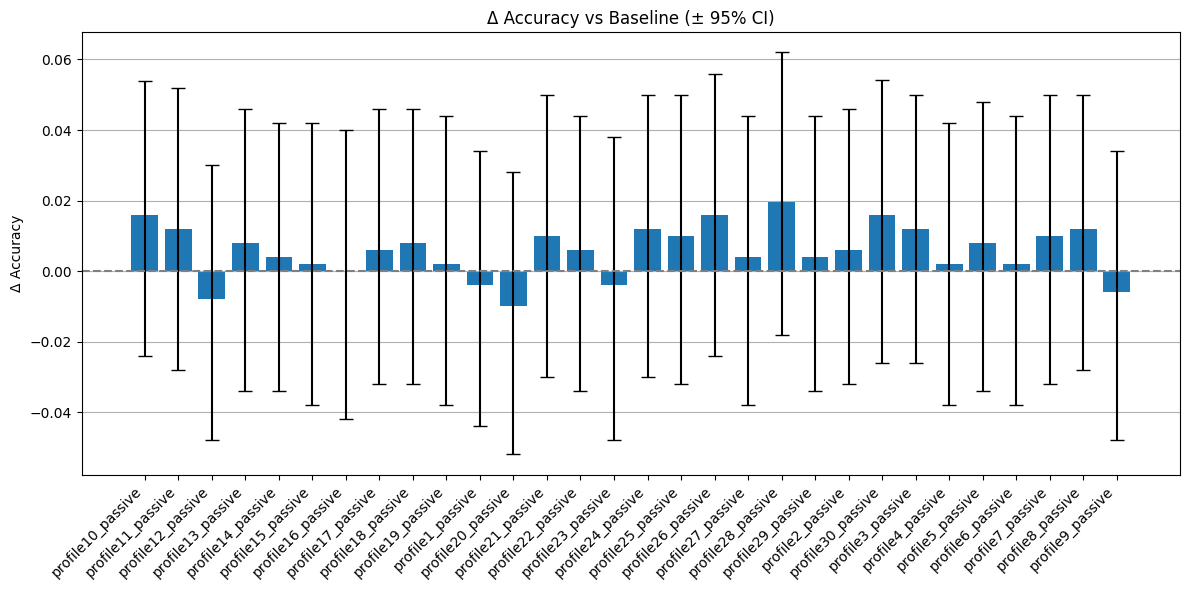

In [31]:
disagreement_cases = extract_high_disagreement_cases(merged_df, threshold=0.3)
print("\n=== HIGH DISAGREEMENT CASES ===")
print(disagreement_cases.head(10))

bias_patterns = detect_systematic_biases(merged_df)
print("\n=== SYSTEMATIC BIAS PATTERNS ===")
print(bias_patterns.head(20))

rescue_stats = rescue_stats_by_category(merged_df, category_col="stereotype_type")
print("\n=== RESCUE STATISTICS BY CATEGORY ===")
print(rescue_stats[rescue_stats['category'] == 'race'].head(10))

plot_accuracy_deltas_with_ci(merged_df)

In [32]:
similarity_results = analyze_persona_similarity(merged_df)
print("\n=== PERSONA CLUSTERING ===")
for cluster_id, cluster_info in similarity_results['clusters'].items():
    print(f"{cluster_id}: {cluster_info['profiles']}")
    print(f"  Average accuracy: {cluster_info['avg_accuracy']:.4f}")

stability_results = analyze_temporal_stability(merged_df, n_folds=5)
print("\n=== TEMPORAL STABILITY ===")
for profile, stats in list(stability_results.items())[:5]:
    print(f"{profile}: mean={stats['mean_accuracy']:.4f}, std={stats['std_accuracy']:.4f}")


=== PERSONA CLUSTERING ===
cluster_1: ['profile11_passive', 'profile14_passive', 'profile15_passive', 'profile20_passive', 'profile30_passive', 'profile9_passive']
  Average accuracy: 0.7030
cluster_2: ['profile25_passive', 'profile26_passive', 'profile28_passive', 'profile4_passive', 'profile6_passive']
  Average accuracy: 0.7100
cluster_3: ['profile10_passive', 'profile12_passive', 'profile13_passive', 'profile16_passive', 'profile17_passive', 'profile18_passive', 'profile19_passive', 'profile1_passive', 'profile21_passive', 'profile22_passive', 'profile23_passive', 'profile24_passive', 'profile27_passive', 'profile29_passive', 'profile2_passive', 'profile3_passive', 'profile5_passive', 'profile7_passive', 'profile8_passive']
  Average accuracy: 0.7057

=== TEMPORAL STABILITY ===
profile10_passive: mean=0.7160, std=0.0233
profile11_passive: mean=0.7120, std=0.0343
profile12_passive: mean=0.6920, std=0.0194
profile13_passive: mean=0.7080, std=0.0232
profile14_passive: mean=0.7040, st

Running Tier 1 Analysis: 3-Way Factorial ANOVA...

FACTORIAL ANOVA: ACCURACY
GENDER MAIN EFFECT:
  Male mean: 0.7051
  Female mean: 0.7067
  Difference: 0.0016
  p-value: 0.5654 
  Cohen's d: 0.220

ETHNICITY MAIN EFFECT:
  White mean: 0.7058
  Black mean: 0.7024
  Asian mean: 0.7094
  F-statistic: 2.428
  p-value: 0.1072 

COGNITIVE STYLE MAIN EFFECT:
  Balanced mean: 0.7070
  Expansive mean: 0.7060
  Literal mean: 0.7040
  High_Harm mean: 0.7093
  Low_Harm mean: 0.7030
  F-statistic: 0.644
  p-value: 0.6363 

INTERACTION EFFECTS:
  Male White: 0.7048
  Male Black: 0.7036
  Male Asian: 0.7068
  Female White: 0.7068
  Female Black: 0.7012
  Female Asian: 0.7120

FACTORIAL ANOVA: RESCUE_RATE
GENDER MAIN EFFECT:
  Male mean: 0.0544
  Female mean: 0.0570
  Difference: 0.0026
  p-value: 0.6808 
  Cohen's d: 0.157

ETHNICITY MAIN EFFECT:
  White mean: 0.0586
  Black mean: 0.0495
  Asian mean: 0.0591
  F-statistic: 1.004
  p-value: 0.3798 

COGNITIVE STYLE MAIN EFFECT:
  Balanced mean: 0.061

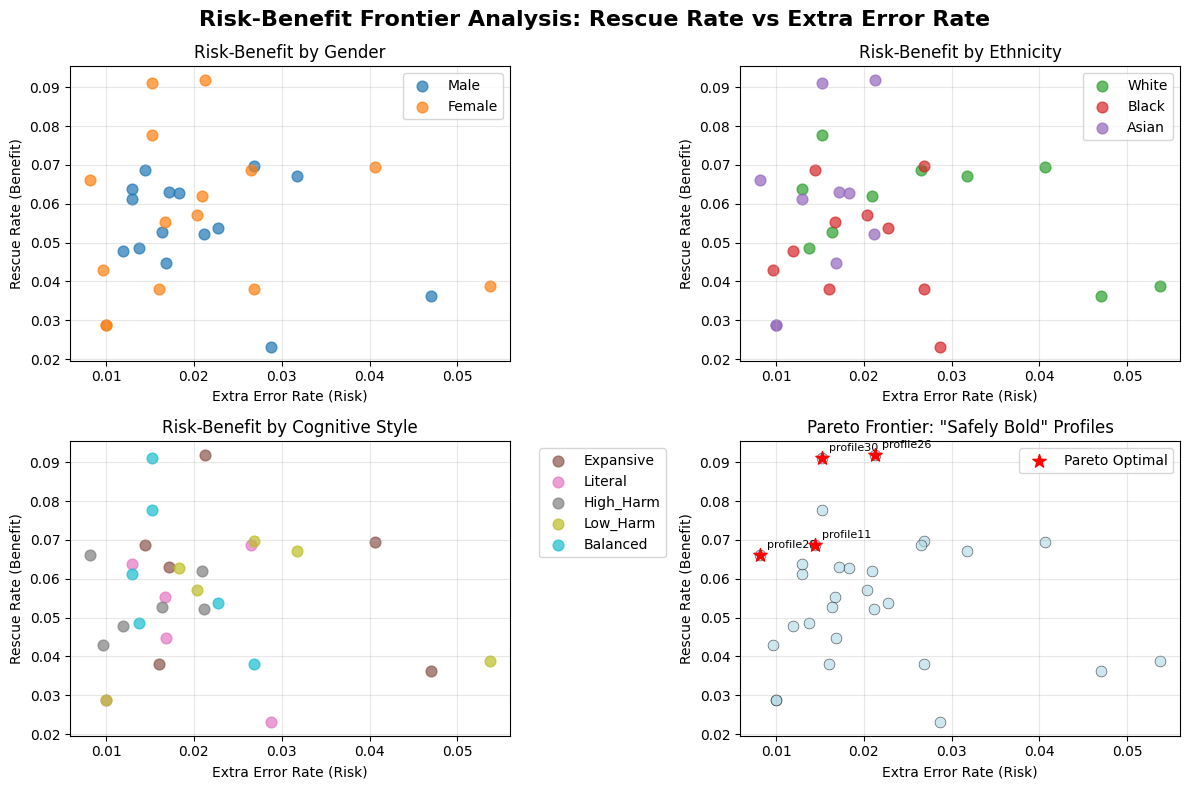


PARETO FRONTIER ANALYSIS

Pareto Optimal Profiles (Safely Bold):
  profile11_passive: Male Black Expansive
    Rescue Rate: 0.069, Extra Error Rate: 0.014
  profile26_passive: Female Asian Expansive
    Rescue Rate: 0.092, Extra Error Rate: 0.021
  profile28_passive: Female Asian High_Harm
    Rescue Rate: 0.066, Extra Error Rate: 0.008
  profile30_passive: Female Asian Balanced
    Rescue Rate: 0.091, Extra Error Rate: 0.015

Risk-Benefit Statistics:
  Average rescue rate: 0.056
  Average extra error rate: 0.021
  Best rescue rate: 0.092
  Lowest extra error rate: 0.008

Profile Archetypes:
  Safest Profile: profile28_passive (Female Asian High_Harm)
    Extra Error Rate: 0.008
  Most Beneficial Profile: profile26_passive (Female Asian Expansive)
    Rescue Rate: 0.092
Calculating Effect Sizes...

EFFECT SIZE ANALYSIS (Cohen's d)

white_vs_black_on_race:
  Cohen's d: 1.168 (large effect)
  Mean difference: 0.0098
  White personas: 0.7074
  Black personas: 0.6975

black_women_race_vs_

In [33]:
from analysis_tools import factorial_analysis_3way_anova, plot_risk_benefit_frontier, calculate_effect_sizes

print("Running Tier 1 Analysis: 3-Way Factorial ANOVA...")
factorial_results = factorial_analysis_3way_anova(merged_df)

print("Creating Risk-Benefit Frontier...")
risk_benefit_results = plot_risk_benefit_frontier(merged_df)

print("Calculating Effect Sizes...")
effect_sizes = calculate_effect_sizes(merged_df, significant_findings)

🚀 Running Tier 2 Analysis...
🚀 EXECUTING TIER 2 ANALYSIS PIPELINE

📊 Running Ensemble by Trait Analysis...
ENSEMBLE BY TRAIT ANALYSIS
Baseline accuracy: 0.7000

Ensemble Performance by Trait Group:
--------------------------------------------------
ALL_PROFILES   : 0.7060 (+0.0060) | Rescue: 0.067 | Extra Err: 0.020 | n=30
MEN_ONLY       : 0.7080 (+0.0080) | Rescue: 0.073 | Extra Err: 0.020 | n=15
WOMEN_ONLY     : 0.7080 (+0.0080) | Rescue: 0.067 | Extra Err: 0.017 | n=15
WHITE_ONLY     : 0.7020 (+0.0020) | Rescue: 0.067 | Extra Err: 0.026 | n=10
BLACK_ONLY     : 0.7020 (+0.0020) | Rescue: 0.053 | Extra Err: 0.020 | n=10
ASIAN_ONLY     : 0.7060 (+0.0060) | Rescue: 0.073 | Extra Err: 0.023 | n=10
EXPANSIVE_ONLY : 0.7000 (+0.0000) | Rescue: 0.067 | Extra Err: 0.029 | n=6
LITERAL_ONLY   : 0.7080 (+0.0080) | Rescue: 0.060 | Extra Err: 0.014 | n=6
HIGH_HARM_ONLY : 0.7080 (+0.0080) | Rescue: 0.060 | Extra Err: 0.014 | n=6
LOW_HARM_ONLY  : 0.7020 (+0.0020) | Rescue: 0.073 | Extra Err: 0.029 |

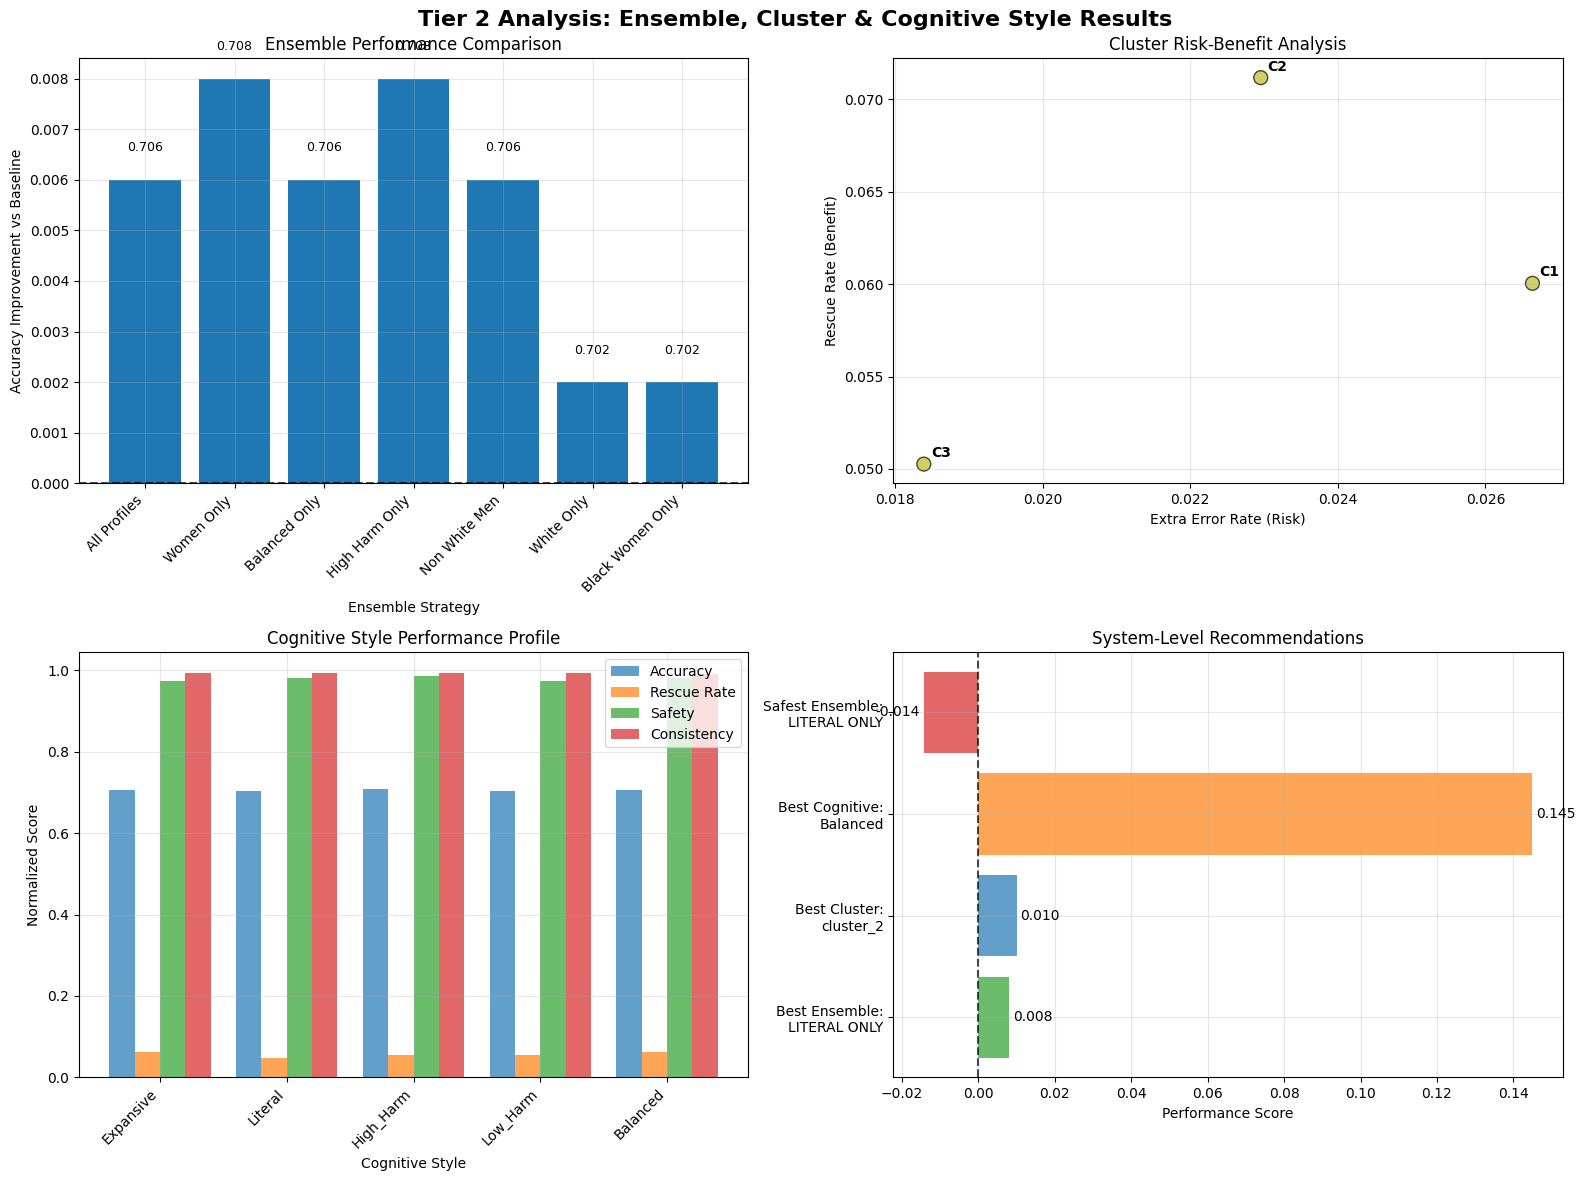


TIER 2 EXECUTIVE SUMMARY

🎯 KEY FINDINGS:
   • Best Ensemble Strategy: LITERAL_ONLY
   • Best Cluster: cluster_2
   • Best Cognitive Style: Balanced

📈 PERFORMANCE GAINS:
   • Best Ensemble Improvement: +0.0080
   • Safety-Performance Balance Achieved

🛡️ SAFETY INSIGHTS:
   • Safest Strategy: LITERAL_ONLY
   • Minimum Extra Error Rate: 0.014
Best ensemble strategy: LITERAL_ONLY
Performance improvement: +0.0080


In [34]:
from analysis_tools import run_tier2_analysis
# Run complete Tier 2 analysis
print("🚀 Running Tier 2 Analysis...")
tier2_results = run_tier2_analysis(merged_df)

# Access key recommendations
executive_summary = tier2_results['executive_summary']
print(f"Best ensemble strategy: {executive_summary['best_ensemble']}")
print(f"Performance improvement: +{executive_summary['performance_improvement']:.4f}")

🚀 Running Tier 3 Analysis...
🚀 EXECUTING TIER 3 ANALYSIS PIPELINE

⏱️ Running Temporal Stability vs Boldness Analysis...
TEMPORAL STABILITY vs BOLDNESS TRADEOFF ANALYSIS
📊 Calculating temporal stability across 5 folds...
⚡ Calculating boldness metrics...
🔗 Analyzing stability-boldness correlations...

📈 CORRELATION RESULTS:
  Volatility vs Boldness: r=-0.142, p=0.4552 
  Volatility vs Rescue Rate: r=-0.142, p=0.4552 
  Boldness vs Accuracy: r=0.686, p=0.0000 ***

🎯 PROFILE CLASSIFICATION:
  profile10: ⚡ Stable Bold - Best of both worlds
    Volatility: 0.0233, Boldness: 0.031, Rescue: 0.078, Accuracy: 0.7160
  profile11: 🌪️ Volatile Bold - High risk, high moral value
    Volatility: 0.0343, Boldness: 0.027, Rescue: 0.069, Accuracy: 0.7120
  profile12: 🛡️ Stable Cautious - Low risk, predictable
    Volatility: 0.0194, Boldness: 0.009, Rescue: 0.023, Accuracy: 0.6920
  profile13: 🛡️ Stable Cautious - Low risk, predictable
    Volatility: 0.0232, Boldness: 0.019, Rescue: 0.048, Accuracy: 

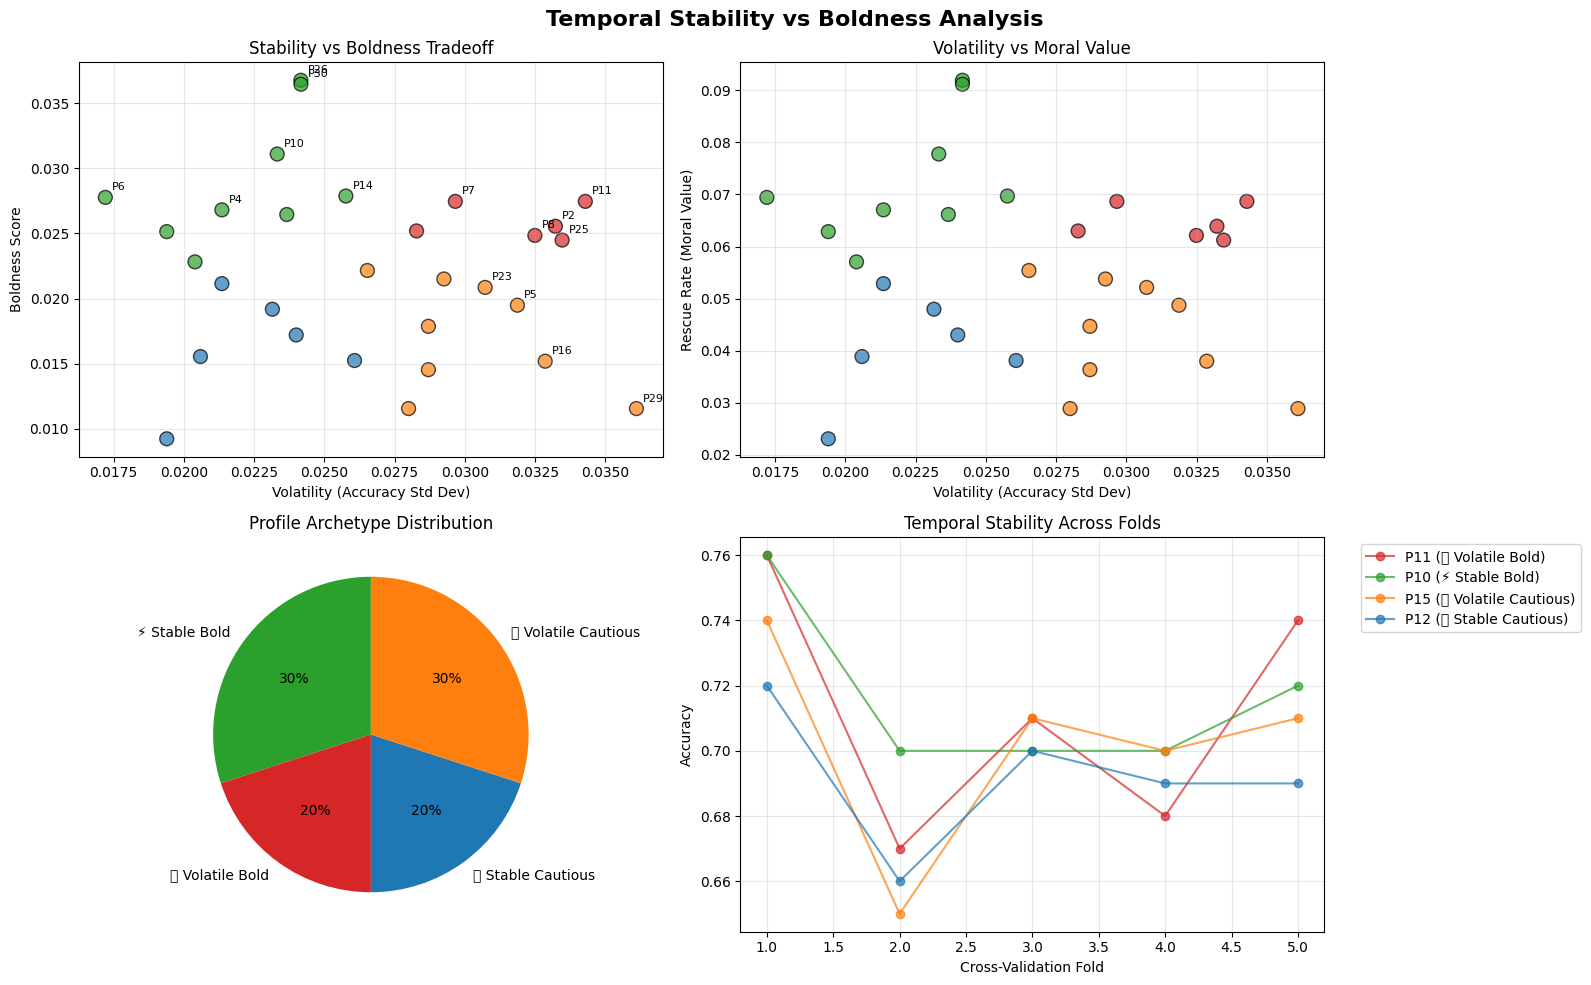


🧠 Creating Causal Model Visualizations...


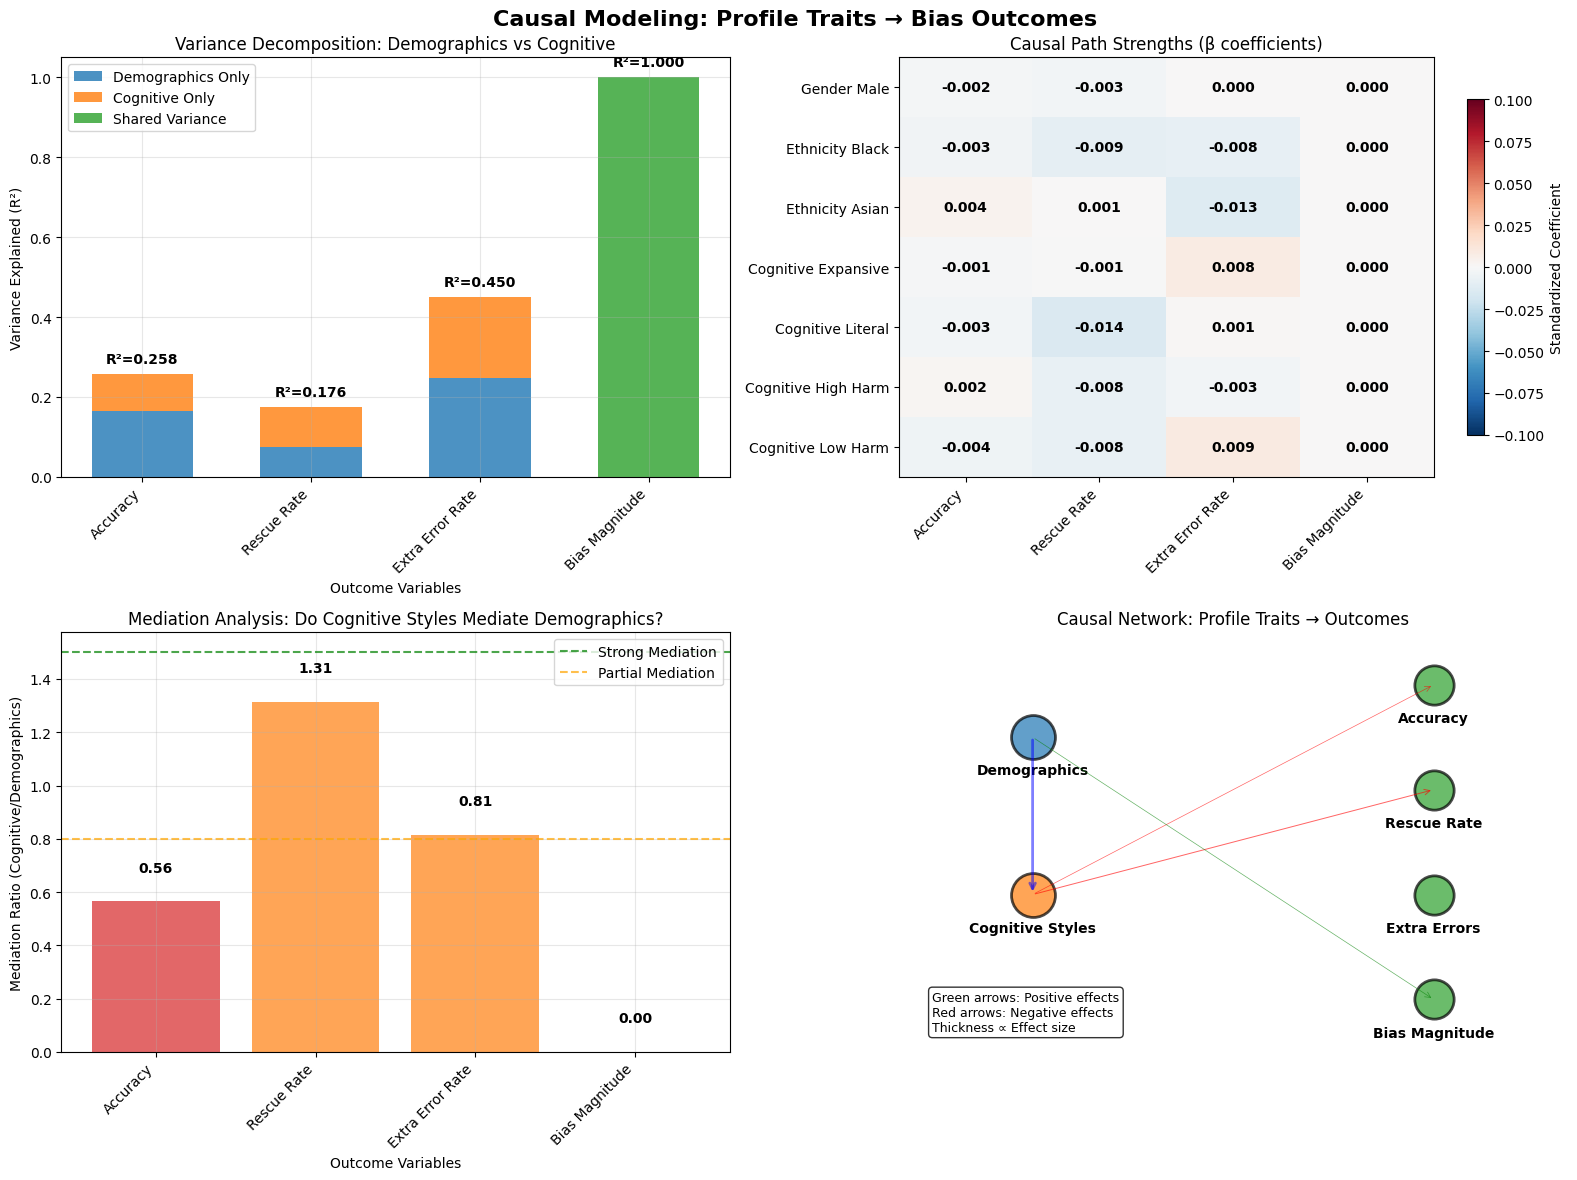


TIER 3 THEORETICAL INTEGRATION

🧠 THEORETICAL INSIGHTS:
   • ❌ Stable profiles outperform volatile ones in moral value
   • Implication: Consistency should be prioritized over boldness in AI systems
   • Strongest predictor of moral value (rescue): cognitive_literal
   • Strongest predictor of performance (accuracy): cognitive_low_harm
   • Mediation effects found: rescue_rate: Partial mediation, extra_error_rate: Partial mediation

THESIS-LEVEL CONCLUSIONS

🎯 CONCLUSION 1: Demographics remain primary drivers of bias
   Evidence: Demographic factors dominate in 2/4 outcomes
   Implication: Diverse demographic representation is crucial for bias mitigation

🎯 CONCLUSION 2: ethnicity_asian is the most critical trait for system design
   Evidence: Appears in 3/3 optimization objectives
   Implication: AI systems should prioritize profiles with ethnicity_asian characteristics


In [35]:
from analysis_tools import run_tier3_analysis
print("🚀 Running Tier 3 Analysis...")
tier3_results = run_tier3_analysis(merged_df)

## Manipulation detection

🔍 Found 12 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'profile1_active', 'profile1_passive', 'profile2_active', 'profile2_passive', 'profile3_active', 'profile3_passive', 'profile4_active', 'profile4_passive', 'profile5_active', 'profile5_passive', 'profile6_active', 'profile6_passive', 'technique', 'vulnerability']



=== Accuracy Improvements vs Baseline
profile1_active: Δ = -0.0140
profile1_passive: Δ = 0.0040
profile2_active: Δ = -0.0040
profile2_passive: Δ = -0.0060
profile3_active: Δ = 0.0100
profile3_passive: Δ = 0.0020
profile4_active: Δ = 0.0000
profile4_passive: Δ = 0.0040
profile5_active: Δ = -0.0200
profile5_passive: Δ = 0.0160
profile6_active: Δ = 0.0000
profile6_passive: Δ = 0.0180

=== McNemar p-values:
profile1_active: p = 0.3916, stat = 21.00
profile1_passive: p = 0.8776, stat = 20.00
profile2_active: p = 0.8899, stat = 25.00
profile2_passive: p = 0.7754, stat = 23.00
profile3_active: p = 0.5682, stat = 22.0

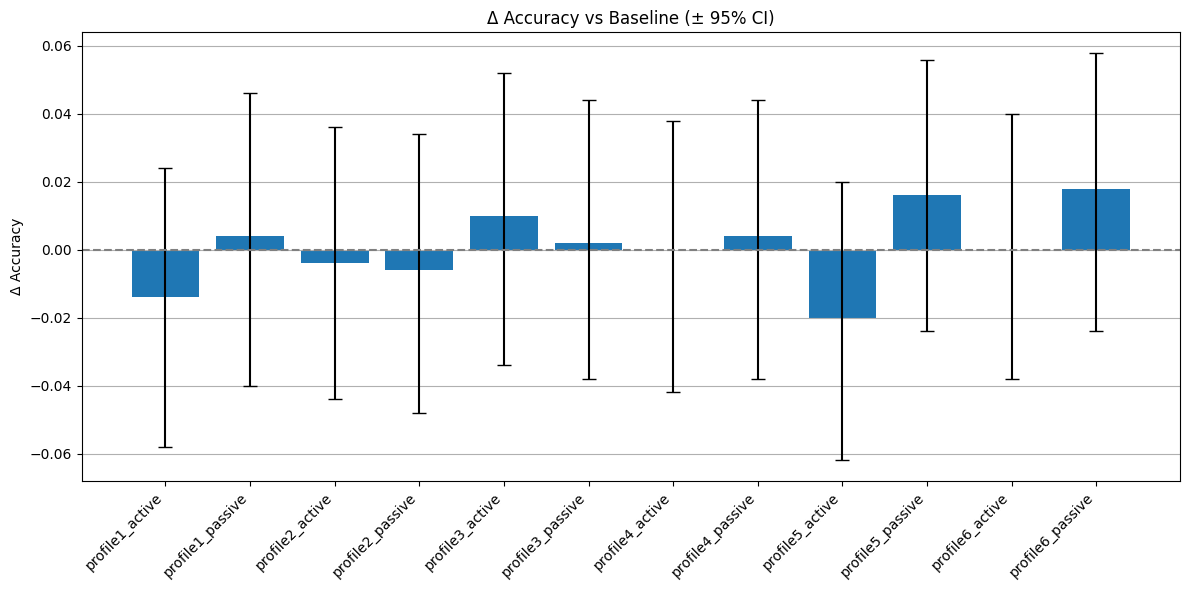

In [36]:
merged_manipulation = load_and_merge_profiles(
    base_file_path="results/openai_4.1_mini/few_shot/classic/results_manipulation_few_shot_prompt_short_3examples.csv",
    role_playing_glob_pattern="results/openai_4.1_mini/few_shot/role_playing_core/*/results_manipulation_few_shot_prompt_short_3examples_binary.csv",
    sample_df=sample_mentalmanip,
    extra_cols=["technique", "vulnerability"]
)
merged_manipulation["task"] = "manipulation"

report = evaluate_role_playing_effects(merged_manipulation)
print("\n\n")
print_report(report)

plot_accuracy_deltas_with_ci(merged_manipulation)
#plot_confusion_matrix(merged["true_label"], merged["base_pred"], title="Confusion Matrix - Baseline")
#plot_confusion_matrix(merged["true_label"], merged["profile3_passive"], title="Confusion Matrix - profile3_passive")
#plot_deltas_per_category(merged, category_col="technique")
#plot_deltas_per_category(merged, category_col="vulnerability")

#summary_df = compute_classification_reports(merged)